
EJECUTANDO ESCENARIO: 3_mixtos

RÉPLICA 1
Usuarios rápidos: 37
Usuarios normales: 63
Usuarios lentos: 53
Usuarios muy lentos: 60

RÉPLICA 2
Usuarios rápidos: 44
Usuarios normales: 75
Usuarios lentos: 27
Usuarios muy lentos: 45

RÉPLICA 3
Usuarios rápidos: 25
Usuarios normales: 68
Usuarios lentos: 47
Usuarios muy lentos: 54

RÉPLICA 4
Usuarios rápidos: 37
Usuarios normales: 60
Usuarios lentos: 44
Usuarios muy lentos: 59

RÉPLICA 5
Usuarios rápidos: 35
Usuarios normales: 66
Usuarios lentos: 46
Usuarios muy lentos: 55

RÉPLICA 6
Usuarios rápidos: 33
Usuarios normales: 71
Usuarios lentos: 53
Usuarios muy lentos: 53

RÉPLICA 7
Usuarios rápidos: 35
Usuarios normales: 60
Usuarios lentos: 55
Usuarios muy lentos: 54

RÉPLICA 8
Usuarios rápidos: 40
Usuarios normales: 77
Usuarios lentos: 55
Usuarios muy lentos: 48

RÉPLICA 9
Usuarios rápidos: 38
Usuarios normales: 67
Usuarios lentos: 37
Usuarios muy lentos: 48

RÉPLICA 10
Usuarios rápidos: 43
Usuarios normales: 60
Usuarios lentos: 37
Usuarios mu

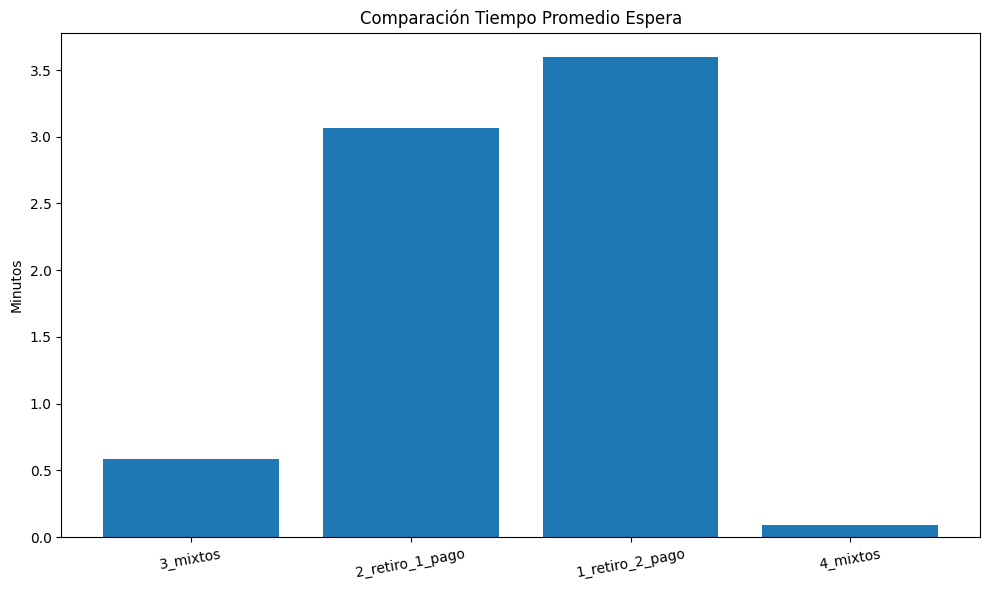

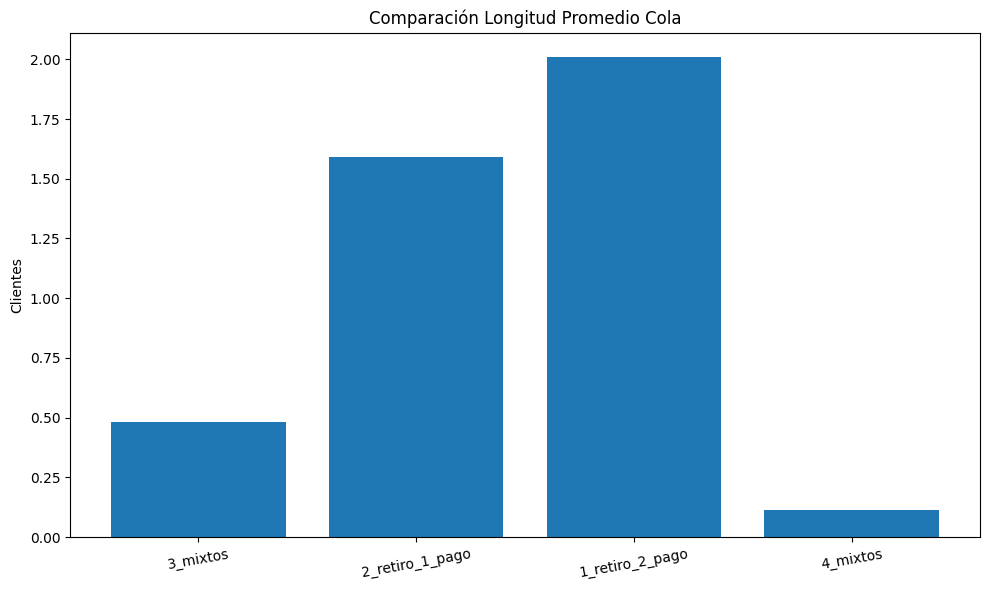

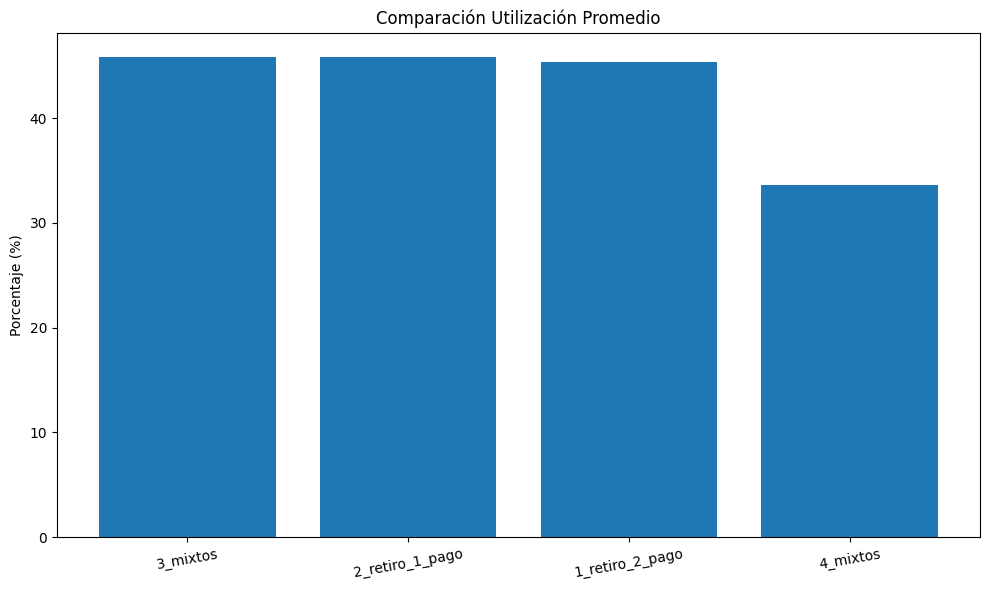

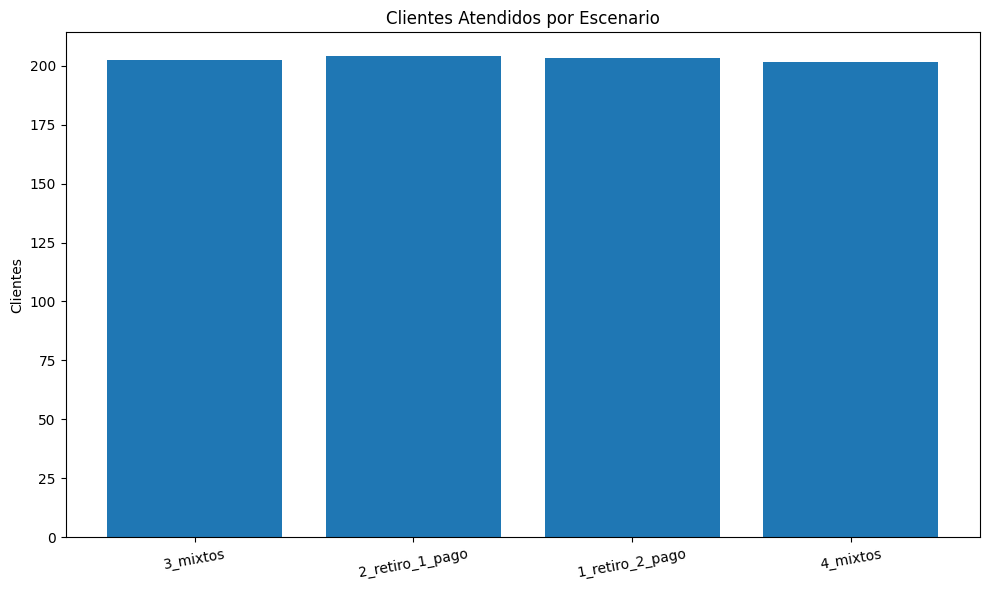

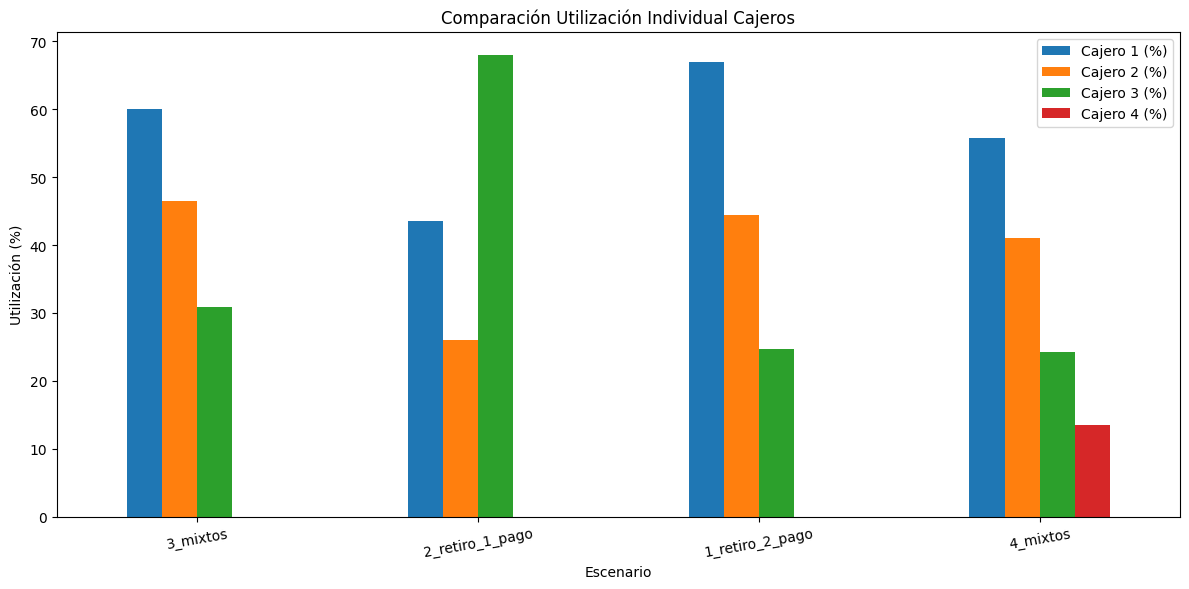


===== MODELO CON MENOR CANTIDAD DE USUARIOS POR TIPO =====
Menor cantidad de usuarios rápidos: 3_mixtos
Menor cantidad de usuarios normales: 1_retiro_2_pago
Menor cantidad de usuarios lentos: 4_mixtos
Menor cantidad de usuarios muy lentos: 2_retiro_1_pago

========== CONCLUSIONES AUTOMÁTICAS ==========

La configuración con menor tiempo de espera fue: 4_mixtos
Tiempo promedio de espera: 0.09 minutos

La configuración con menor longitud de cola fue: 4_mixtos
Longitud promedio cola: 0.11

La configuración más estable según utilización fue: 4_mixtos
Utilización promedio: 33.62%

Recomendación final:
La mejor configuración general es 4_mixtos ya que presentó el menor tiempo de espera promedio para los clientes.

========== UTILIZACIÓN INDIVIDUAL CAJEROS ==========

Escenario: 3_mixtos
Cajero 1 (%): 60.07%
Cajero 2 (%): 46.44%
Cajero 3 (%): 30.93%
Diferencia máxima: 29.14%
Sistema balanceado.

Escenario: 2_retiro_1_pago
Cajero 1 (%): 43.48%
Cajero 2 (%): 26.06%
Cajero 3 (%): 68.01%
Diferen

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque


class BancoSimulacion:

    def __init__(self, configuracion, tiempo_simulacion=480):

        self.configuracion = configuracion
        self.tiempo_simulacion = tiempo_simulacion

        # -------------------------------------------------
        # CONFIGURACIONES
        # -------------------------------------------------

        self.escenarios = {

            "3_mixtos":
                ["mixto", "mixto", "mixto"],

            "2_retiro_1_pago":
                ["retiro", "retiro", "pago"],

            "1_retiro_2_pago":
                ["retiro", "pago", "pago"],

            "4_mixtos":
                ["mixto", "mixto", "mixto", "mixto"]
        }

        self.cajeros = self.escenarios[configuracion]

        self.num_cajeros = len(self.cajeros)

        # -------------------------------------------------
        # PROBABILIDADES
        # -------------------------------------------------

        self.prob_retiro = 0.70
        self.prob_pago = 0.30

        # Tipos retiro
        self.prob_tipos_retiro = [0.23, 0.40, 0.17, 0.20]

        # Tipos pago
        self.prob_tipos_pago = [0.10, 0.20, 0.30, 0.40]

        # Servicio retiro
        self.servicio_retiro = [1, 2, 3, 4]

        # Llegada retiro
        self.llegada_retiro = [1, 2, 3, 3]

        # Servicio pago
        self.servicio_pago = [3, 3, 5, 7]

        # Llegada pago
        self.llegada_pago = [1, 2, 3, 4]

        self.resetear_simulacion()

    # =====================================================
    # RESETEAR
    # =====================================================

    def resetear_simulacion(self):

        self.tiempo_actual = 0

        self.eventos = []

        self.cola_retiro = deque()

        self.cola_pago = deque()

        self.cajeros_ocupados = [False] * self.num_cajeros

        self.tiempo_ocupado_cajeros = [0] * self.num_cajeros

        self.inicio_ocupacion = [0] * self.num_cajeros

        self.estadisticas = {

            "clientes_atendidos": 0,

            "clientes_retiro": 0,

            "clientes_pago": 0,

            "tiempos_espera": [],

            "tiempos_servicio": [],

            "tiempos_sistema": [],

            "longitud_cola": [],

            "tipos_usuario": {

                "rapido": 0,

                "normal": 0,

                "lento": 0,

                "muy_lento": 0
            }
        }

    # =====================================================
    # GENERAR OPERACIÓN
    # =====================================================

    def generar_tipo_operacion(self):

        r = np.random.random()

        if r < self.prob_retiro:

            return "retiro"

        return "pago"

    # =====================================================
    # GENERAR TIPO USUARIO
    # =====================================================

    def generar_tipo_usuario(self, operacion):

        r = np.random.random()

        if operacion == "retiro":

            probs = self.prob_tipos_retiro

        else:

            probs = self.prob_tipos_pago

        acumulado = 0

        for i, p in enumerate(probs):

            acumulado += p

            if r <= acumulado:

                tipos = [

                    "rapido",

                    "normal",

                    "lento",

                    "muy_lento"
                ]

                return i, tipos[i]

        return 3, "muy_lento"

    # =====================================================
    # TIEMPO SERVICIO
    # =====================================================

    def generar_tiempo_servicio(
        self,
        operacion,
        tipo
    ):

        if operacion == "retiro":

            media = self.servicio_retiro[tipo]

        else:

            media = self.servicio_pago[tipo]

        return np.random.exponential(media)

    # =====================================================
    # TIEMPO LLEGADA
    # =====================================================

    def generar_tiempo_llegada(
        self,
        operacion,
        tipo
    ):

        if operacion == "retiro":

            media = self.llegada_retiro[tipo]

        else:

            media = self.llegada_pago[tipo]

        return np.random.exponential(media)

    # =====================================================
    # PROGRAMAR EVENTO
    # =====================================================

    def programar_evento(
        self,
        tiempo,
        tipo_evento,
        datos
    ):

        self.eventos.append(
            (
                tiempo,
                tipo_evento,
                datos
            )
        )

        self.eventos.sort(
            key=lambda x: x[0]
        )

    # =====================================================
    # BUSCAR CAJERO
    # =====================================================

    def buscar_cajero_disponible(
        self,
        operacion
    ):

        for i in range(self.num_cajeros):

            if not self.cajeros_ocupados[i]:

                tipo_cajero = self.cajeros[i]

                if tipo_cajero == "mixto":

                    return i

                if tipo_cajero == operacion:

                    return i

        return None

    # =====================================================
    # INICIAR SERVICIO
    # =====================================================

    def iniciar_servicio(
        self,
        cajero,
        cliente
    ):

        self.cajeros_ocupados[cajero] = True

        self.inicio_ocupacion[cajero] = (
            self.tiempo_actual
        )

        tiempo_espera = (

            self.tiempo_actual

            - cliente["tiempo_llegada"]
        )

        tiempo_servicio = (

            self.generar_tiempo_servicio(

                cliente["operacion"],

                cliente["tipo"]
            )
        )

        self.estadisticas[
            "tiempos_espera"
        ].append(tiempo_espera)

        self.estadisticas[
            "tiempos_servicio"
        ].append(tiempo_servicio)

        self.estadisticas[
            "clientes_atendidos"
        ] += 1

        tiempo_sistema = (

            tiempo_espera

            + tiempo_servicio
        )

        self.estadisticas[
            "tiempos_sistema"
        ].append(tiempo_sistema)

        fin_servicio = (

            self.tiempo_actual

            + tiempo_servicio
        )

        self.programar_evento(

            fin_servicio,

            "fin_servicio",

            {
                "cajero": cajero,

                "operacion":
                    cliente["operacion"]
            }
        )

    # =====================================================
    # PROCESAR LLEGADA
    # =====================================================

    def procesar_llegada(self):

        operacion = (
            self.generar_tipo_operacion()
        )

        tipo, nombre_tipo = (
            self.generar_tipo_usuario(
                operacion
            )
        )

        self.estadisticas[
            "tipos_usuario"
        ][nombre_tipo] += 1

        if operacion == "retiro":

            self.estadisticas[
                "clientes_retiro"
            ] += 1

        else:

            self.estadisticas[
                "clientes_pago"
            ] += 1

        cliente = {

            "tiempo_llegada":
                self.tiempo_actual,

            "operacion":
                operacion,

            "tipo":
                tipo,

            "nombre_tipo":
                nombre_tipo
        }

        cajero = self.buscar_cajero_disponible(
            operacion
        )

        if cajero is not None:

            self.iniciar_servicio(
                cajero,
                cliente
            )

        else:

            if operacion == "retiro":

                self.cola_retiro.append(cliente)

            else:

                self.cola_pago.append(cliente)

        longitud_total = (

            len(self.cola_retiro)

            + len(self.cola_pago)
        )

        self.estadisticas[
            "longitud_cola"
        ].append(longitud_total)

        # Próxima llegada

        siguiente_operacion = (
            self.generar_tipo_operacion()
        )

        siguiente_tipo, _ = (
            self.generar_tipo_usuario(
                siguiente_operacion
            )
        )

        tiempo_siguiente = (

            self.tiempo_actual

            + self.generar_tiempo_llegada(

                siguiente_operacion,

                siguiente_tipo
            )
        )

        if tiempo_siguiente <= self.tiempo_simulacion:

            self.programar_evento(

                tiempo_siguiente,

                "llegada",

                {}
            )

    # =====================================================
    # FIN SERVICIO
    # =====================================================

    def procesar_fin_servicio(
        self,
        datos
    ):

        cajero = datos["cajero"]

        self.cajeros_ocupados[cajero] = False

        tiempo_ocupado = (

            self.tiempo_actual

            - self.inicio_ocupacion[cajero]
        )

        self.tiempo_ocupado_cajeros[cajero] += (
            tiempo_ocupado
        )

        tipo_cajero = self.cajeros[cajero]

        siguiente_cliente = None

        if tipo_cajero == "mixto":

            if len(self.cola_retiro) > 0:

                siguiente_cliente = (
                    self.cola_retiro.popleft()
                )

            elif len(self.cola_pago) > 0:

                siguiente_cliente = (
                    self.cola_pago.popleft()
                )

        elif tipo_cajero == "retiro":

            if len(self.cola_retiro) > 0:

                siguiente_cliente = (
                    self.cola_retiro.popleft()
                )

        elif tipo_cajero == "pago":

            if len(self.cola_pago) > 0:

                siguiente_cliente = (
                    self.cola_pago.popleft()
                )

        if siguiente_cliente:

            self.iniciar_servicio(
                cajero,
                siguiente_cliente
            )

    # =====================================================
    # CALCULAR MÉTRICAS
    # =====================================================

    def calcular_metricas(self):

        tiempo_promedio_espera = (

            np.mean(
                self.estadisticas[
                    "tiempos_espera"
                ]
            )

            if self.estadisticas[
                "tiempos_espera"
            ]

            else 0
        )

        tiempo_promedio_servicio = (

            np.mean(
                self.estadisticas[
                    "tiempos_servicio"
                ]
            )

            if self.estadisticas[
                "tiempos_servicio"
            ]

            else 0
        )

        tiempo_promedio_sistema = (

            np.mean(
                self.estadisticas[
                    "tiempos_sistema"
                ]
            )

            if self.estadisticas[
                "tiempos_sistema"
            ]

            else 0
        )

        longitud_promedio_cola = (

            np.mean(
                self.estadisticas[
                    "longitud_cola"
                ]
            )

            if self.estadisticas[
                "longitud_cola"
            ]

            else 0
        )

        desviacion_espera = (

            np.std(
                self.estadisticas[
                    "tiempos_espera"
                ]
            )

            if self.estadisticas[
                "tiempos_espera"
            ]

            else 0
        )

        # -------------------------------------------------
        # UTILIZACIÓN INDIVIDUAL
        # -------------------------------------------------

        utilizacion_cajeros = []

        for t in self.tiempo_ocupado_cajeros:

            utilizacion = (

                t / self.tiempo_simulacion

            ) * 100

            utilizacion_cajeros.append(
                utilizacion
            )

        utilizacion_promedio = np.mean(
            utilizacion_cajeros
        )

        # -------------------------------------------------
        # MÉTRICAS TEORÍA DE COLAS
        # -------------------------------------------------

        lambda_aprox = (

            self.estadisticas[
                "clientes_atendidos"
            ]

            / self.tiempo_simulacion
        )

        if tiempo_promedio_servicio > 0:

            mu_aprox = (
                1 / tiempo_promedio_servicio
            )

        else:

            mu_aprox = 0

        if mu_aprox > 0:

            rho = (

                lambda_aprox

                / (
                    mu_aprox
                    * self.num_cajeros
                )
            )

        else:

            rho = 0

        L = (

            lambda_aprox

            * tiempo_promedio_sistema
        )

        Lq = (

            lambda_aprox

            * tiempo_promedio_espera
        )

        W = tiempo_promedio_sistema

        Wq = tiempo_promedio_espera

        return {

            "clientes_atendidos":
                self.estadisticas[
                    "clientes_atendidos"
                ],

            "clientes_retiro":
                self.estadisticas[
                    "clientes_retiro"
                ],

            "clientes_pago":
                self.estadisticas[
                    "clientes_pago"
                ],

            "espera_promedio":
                tiempo_promedio_espera,

            "servicio_promedio":
                tiempo_promedio_servicio,

            "sistema_promedio":
                tiempo_promedio_sistema,

            "cola_promedio":
                longitud_promedio_cola,

            "desviacion_espera":
                desviacion_espera,

            "utilizacion_promedio":
                utilizacion_promedio,

            "utilizacion_cajeros":
                utilizacion_cajeros,

            "lambda":
                lambda_aprox,

            "mu":
                mu_aprox,

            "rho":
                rho,

            "L":
                L,

            "Lq":
                Lq,

            "W":
                W,

            "Wq":
                Wq,

            "tipos_usuario":
                self.estadisticas[
                    "tipos_usuario"
                ]
        }

    # =====================================================
    # EJECUTAR
    # =====================================================

    def ejecutar(self):

        self.resetear_simulacion()

        self.programar_evento(
            0,
            "llegada",
            {}
        )

        while self.eventos:

            tiempo, tipo_evento, datos = (
                self.eventos.pop(0)
            )

            self.tiempo_actual = tiempo

            if tipo_evento == "llegada":

                self.procesar_llegada()

            elif tipo_evento == "fin_servicio":

                self.procesar_fin_servicio(
                    datos
                )

        return self.calcular_metricas()


# =========================================================
# RÉPLICAS
# =========================================================

def ejecutar_replicas(
    configuracion,
    replicas=10
):

    resultados = []

    for i in range(replicas):

        np.random.seed(i + 1)

        simulacion = BancoSimulacion(
            configuracion
        )

        resultado = simulacion.ejecutar()

        resultados.append(resultado)
        print(f"\nRÉPLICA {i+1}")
        print(f"Usuarios rápidos: {resultado['tipos_usuario']['rapido']}")
        print(f"Usuarios normales: {resultado['tipos_usuario']['normal']}")
        print(f"Usuarios lentos: {resultado['tipos_usuario']['lento']}")
        print(f"Usuarios muy lentos: {resultado['tipos_usuario']['muy_lento']}")

    return resultados


# =========================================================
# IC95%
# =========================================================

def calcular_ic95(datos):

    media = np.mean(datos)

    desviacion = np.std(
        datos,
        ddof=1
    )

    n = len(datos)

    margen_error = (

        1.96

        * (
            desviacion
            / np.sqrt(n)
        )
    )

    inferior = media - margen_error

    superior = media + margen_error

    return (
        media,
        desviacion,
        inferior,
        superior
    )


# =========================================================
# RESUMEN
# =========================================================

def resumir_resultados(resultados):

    espera = [
        r["espera_promedio"]
        for r in resultados
    ]

    servicio = [
        r["servicio_promedio"]
        for r in resultados
    ]

    cola = [
        r["cola_promedio"]
        for r in resultados
    ]

    utilizacion = [
        r["utilizacion_promedio"]
        for r in resultados
    ]

    clientes = [
        r["clientes_atendidos"]
        for r in resultados
    ]

    rho = [
        r["rho"]
        for r in resultados
    ]

    L = [
        r["L"]
        for r in resultados
    ]

    Lq = [
        r["Lq"]
        for r in resultados
    ]

    W = [
        r["W"]
        for r in resultados
    ]

    Wq = [
        r["Wq"]
        for r in resultados
    ]

    resumen = {}
    rapidos = [r["tipos_usuario"]["rapido"] for r in resultados]
    normales = [r["tipos_usuario"]["normal"] for r in resultados]
    lentos = [r["tipos_usuario"]["lento"] for r in resultados]
    muy_lentos = [r["tipos_usuario"]["muy_lento"] for r in resultados]

    resumen["promedio_rapidos"] = np.mean(rapidos)
    resumen["promedio_normales"] = np.mean(normales)
    resumen["promedio_lentos"] = np.mean(lentos)
    resumen["promedio_muy_lentos"] = np.mean(muy_lentos)

    # -----------------------------------------------------
    # ESPERA
    # -----------------------------------------------------

    media, desv, ic_inf, ic_sup = (
        calcular_ic95(espera)
    )

    resumen["espera_promedio"] = media
    resumen["espera_std"] = desv
    resumen["espera_ic_inf"] = ic_inf
    resumen["espera_ic_sup"] = ic_sup

    # -----------------------------------------------------
    # SERVICIO
    # -----------------------------------------------------

    media, desv, ic_inf, ic_sup = (
        calcular_ic95(servicio)
    )

    resumen["servicio_promedio"] = media
    resumen["servicio_std"] = desv
    resumen["servicio_ic_inf"] = ic_inf
    resumen["servicio_ic_sup"] = ic_sup

    # -----------------------------------------------------
    # COLA
    # -----------------------------------------------------

    media, desv, ic_inf, ic_sup = (
        calcular_ic95(cola)
    )

    resumen["cola_promedio"] = media
    resumen["cola_std"] = desv
    resumen["cola_ic_inf"] = ic_inf
    resumen["cola_ic_sup"] = ic_sup

    # -----------------------------------------------------
    # UTILIZACIÓN
    # -----------------------------------------------------

    media, desv, ic_inf, ic_sup = (
        calcular_ic95(utilizacion)
    )

    resumen["utilizacion_promedio"] = media
    resumen["utilizacion_std"] = desv
    resumen["utilizacion_ic_inf"] = ic_inf
    resumen["utilizacion_ic_sup"] = ic_sup

    # -----------------------------------------------------
    # CLIENTES
    # -----------------------------------------------------

    media, desv, ic_inf, ic_sup = (
        calcular_ic95(clientes)
    )

    resumen["clientes_atendidos"] = media
    resumen["clientes_std"] = desv
    resumen["clientes_ic_inf"] = ic_inf
    resumen["clientes_ic_sup"] = ic_sup

    # -----------------------------------------------------
    # MÉTRICAS COLAS
    # -----------------------------------------------------

    resumen["rho"] = np.mean(rho)

    resumen["L"] = np.mean(L)

    resumen["Lq"] = np.mean(Lq)

    resumen["W"] = np.mean(W)

    resumen["Wq"] = np.mean(Wq)

    # -----------------------------------------------------
    # UTILIZACIÓN INDIVIDUAL CAJEROS
    # -----------------------------------------------------

    cantidad_cajeros = len(
        resultados[0]["utilizacion_cajeros"]
    )

    utilizaciones_individuales = []

    for i in range(cantidad_cajeros):

        util_cajero = np.mean([

            r["utilizacion_cajeros"][i]

            for r in resultados

        ])

        utilizaciones_individuales.append(
            util_cajero
        )

    resumen["utilizacion_cajeros"] = (
        utilizaciones_individuales
    )

    return resumen


# =========================================================
# CONCLUSIONES
# =========================================================

def generar_conclusiones(df):

    mejor_espera = df.loc[
        df["Espera Promedio"].idxmin()
    ]

    mejor_cola = df.loc[
        df["Cola Promedio"].idxmin()
    ]

    mejor_utilizacion = df.loc[
        df["Utilización Promedio (%)"].idxmin()
    ]

    print(
        "\n========== "
        "CONCLUSIONES AUTOMÁTICAS "
        "=========="
    )

    print(
        f"\nLa configuración con menor "
        f"tiempo de espera fue: "
        f"{mejor_espera['Escenario']}"
    )

    print(
        f"Tiempo promedio de espera: "
        f"{mejor_espera['Espera Promedio']:.2f} minutos"
    )

    print(
        f"\nLa configuración con menor "
        f"longitud de cola fue: "
        f"{mejor_cola['Escenario']}"
    )

    print(
        f"Longitud promedio cola: "
        f"{mejor_cola['Cola Promedio']:.2f}"
    )

    print(
        f"\nLa configuración más estable "
        f"según utilización fue: "
        f"{mejor_utilizacion['Escenario']}"
    )

    print(
        f"Utilización promedio: "
        f"{mejor_utilizacion['Utilización Promedio (%)']:.2f}%"
    )

    print("\nRecomendación final:")

    print(
        f"La mejor configuración general es "
        f"{mejor_espera['Escenario']} "
        f"ya que presentó el menor tiempo "
        f"de espera promedio para los clientes."
    )

    # -----------------------------------------------------
    # UTILIZACIÓN INDIVIDUAL
    # -----------------------------------------------------

    print(
        "\n========== "
        "UTILIZACIÓN INDIVIDUAL "
        "CAJEROS =========="
    )

    for _, fila in df.iterrows():

      print(
        f"\nEscenario: "
        f"{fila['Escenario']}"
        )

      # Detectar cantidad real de cajeros
      if fila["Escenario"] == "4_mixtos":

          columnas_cajeros = [
            "Cajero 1 (%)",
            "Cajero 2 (%)",
            "Cajero 3 (%)",
            "Cajero 4 (%)"
        ]

      else:

          columnas_cajeros = [
            "Cajero 1 (%)",
            "Cajero 2 (%)",
            "Cajero 3 (%)"
          ]

      utilizaciones_validas = []

      for col in columnas_cajeros:

          print(
            f"{col}: "
            f"{fila[col]:.2f}%"
         )

          utilizaciones_validas.append(
            fila[col]
        )

      max_util = max(utilizaciones_validas)

      min_util = min(utilizaciones_validas)

      diferencia = (
            max_util - min_util
        )

      print(
            f"Diferencia máxima: "
            f"{diferencia:.2f}%"
        )

      if diferencia > 30:

            print(
                "Sistema desbalanceado."
            )

      else:

            print(
                "Sistema balanceado."
            )


# =========================================================
# GRÁFICAS
# =========================================================

def generar_graficas(df):

    # Espera

    plt.figure(figsize=(10, 6))

    plt.bar(
        df["Escenario"],
        df["Espera Promedio"]
    )

    plt.title(
        "Comparación Tiempo Promedio Espera"
    )

    plt.ylabel("Minutos")

    plt.xticks(rotation=10)

    plt.tight_layout()

    plt.show()

    # Cola

    plt.figure(figsize=(10, 6))

    plt.bar(
        df["Escenario"],
        df["Cola Promedio"]
    )

    plt.title(
        "Comparación Longitud Promedio Cola"
    )

    plt.ylabel("Clientes")

    plt.xticks(rotation=10)

    plt.tight_layout()

    plt.show()

    # Utilización promedio

    plt.figure(figsize=(10, 6))

    plt.bar(
        df["Escenario"],
        df["Utilización Promedio (%)"]
    )

    plt.title(
        "Comparación Utilización Promedio"
    )

    plt.ylabel("Porcentaje (%)")

    plt.xticks(rotation=10)

    plt.tight_layout()

    plt.show()

    # Clientes atendidos

    plt.figure(figsize=(10, 6))

    plt.bar(
        df["Escenario"],
        df["Clientes Atendidos"]
    )

    plt.title(
        "Clientes Atendidos por Escenario"
    )

    plt.ylabel("Clientes")

    plt.xticks(rotation=10)

    plt.tight_layout()

    plt.show()

    # -----------------------------------------------------
    # UTILIZACIÓN INDIVIDUAL
    # -----------------------------------------------------

    columnas_cajeros = [

        col for col in df.columns

        if "Cajero" in col
    ]

    df_cajeros = df.set_index(
        "Escenario"
    )[columnas_cajeros]

    df_cajeros.plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title(
        "Comparación Utilización Individual Cajeros"
    )

    plt.ylabel("Utilización (%)")

    plt.xticks(rotation=10)

    plt.tight_layout()

    plt.show()


# =========================================================
# MAIN
# =========================================================

def main():

    escenarios = [

        "3_mixtos",

        "2_retiro_1_pago",

        "1_retiro_2_pago",

        "4_mixtos"
    ]

    resultados_finales = []

    for escenario in escenarios:

        print(
            f"\n=============================="
        )

        print(
            f"EJECUTANDO ESCENARIO: "
            f"{escenario}"
        )

        print(
            f"=============================="
        )

        replicas = ejecutar_replicas(
            escenario,
            replicas=10
        )

        resumen = resumir_resultados(
            replicas
        )

        resultados_finales.append({

            "Escenario": escenario,

            "Clientes Atendidos":
                resumen[
                    "clientes_atendidos"
                ],

            "Usuarios Rápidos": resumen[
                "promedio_rapidos"],
            "Usuarios Normales": resumen["promedio_normales"],
            "Usuarios Lentos": resumen["promedio_lentos"],
            "Usuarios Muy Lentos": resumen["promedio_muy_lentos"],

            "Espera Promedio":
                resumen[
                    "espera_promedio"
                ],

            "Servicio Promedio":
                resumen[
                    "servicio_promedio"
                ],

            "Cola Promedio":
                resumen[
                    "cola_promedio"
                ],

            "Utilización Promedio (%)":
                resumen[
                    "utilizacion_promedio"
                ],

            "ρ":
                resumen["rho"],

            "L":
                resumen["L"],

            "Lq":
                resumen["Lq"],

            "W":
                resumen["W"],

            "Wq":
                resumen["Wq"],

            # ---------------------------------------------
            # UTILIZACIÓN INDIVIDUAL
            # ---------------------------------------------

            "Cajero 1 (%)":
                resumen[
                    "utilizacion_cajeros"
                ][0],

            "Cajero 2 (%)":
                resumen[
                    "utilizacion_cajeros"
                ][1],

            "Cajero 3 (%)":
                resumen[
                    "utilizacion_cajeros"
                ][2],

            "Cajero 4 (%)":

                resumen[
                    "utilizacion_cajeros"
                ][3]

                if len(
                    resumen[
                        "utilizacion_cajeros"
                    ]
                ) > 3

                else 0
        })

        # -------------------------------------------------
        # RESULTADOS
        # -------------------------------------------------

        print(
            f"Clientes atendidos: "
            f"{resumen['clientes_atendidos']:.2f} "
            f"clientes"
        )

        print(
            f"Tiempo espera promedio: "
            f"{resumen['espera_promedio']:.2f} "
            f"minutos"
        )

        print(
            f"Desviación estándar espera: "
            f"{resumen['espera_std']:.2f} "
            f"minutos"
        )

        print(
            f"IC95% espera: "
            f"[{resumen['espera_ic_inf']:.2f} , "
            f"{resumen['espera_ic_sup']:.2f}] "
            f"minutos"
        )

        print(
            f"Tiempo servicio promedio: "
            f"{resumen['servicio_promedio']:.2f} "
            f"minutos"
        )

        print(
            f"Desviación estándar servicio: "
            f"{resumen['servicio_std']:.2f} "
            f"minutos"
        )

        print(
            f"IC95% servicio: "
            f"[{resumen['servicio_ic_inf']:.2f} , "
            f"{resumen['servicio_ic_sup']:.2f}] "
            f"minutos"
        )

        print(
            f"Longitud cola promedio: "
            f"{resumen['cola_promedio']:.2f} "
            f"clientes"
        )

        print(
            f"Desviación estándar cola: "
            f"{resumen['cola_std']:.2f}"
        )

        print(
            f"IC95% cola: "
            f"[{resumen['cola_ic_inf']:.2f} , "
            f"{resumen['cola_ic_sup']:.2f}] "
            f"clientes"
        )

        print(
            f"Utilización promedio: "
            f"{resumen['utilizacion_promedio']:.2f} %"
        )

        print(
            f"Desviación estándar utilización: "
            f"{resumen['utilizacion_std']:.2f} %"
        )

        print(
            f"IC95% utilización: "
            f"[{resumen['utilizacion_ic_inf']:.2f} , "
            f"{resumen['utilizacion_ic_sup']:.2f}] %"
        )

        print(
            f"ρ: "
            f"{resumen['rho']:.4f}"
        )

        print(
            f"L: "
            f"{resumen['L']:.4f} clientes"
        )

        print(
            f"Lq: "
            f"{resumen['Lq']:.4f} clientes"
        )

        print(
            f"W: "
            f"{resumen['W']:.4f} minutos"
        )

        print(
            f"Wq: "
            f"{resumen['Wq']:.4f} minutos"
        )

        print("\nPROMEDIO USUARIOS POR TIPO")
        print(f"Usuarios rápidos: {resumen['promedio_rapidos']:.2f}")
        print(f"Usuarios normales: {resumen['promedio_normales']:.2f}")
        print(f"Usuarios lentos: {resumen['promedio_lentos']:.2f}")
        print(f"Usuarios muy lentos: {resumen['promedio_muy_lentos']:.2f}")

        # -------------------------------------------------
        # UTILIZACIÓN INDIVIDUAL
        # -------------------------------------------------

        print(
            "\nUtilización individual cajeros:"
        )

        for i, util in enumerate(

            resumen[
                "utilizacion_cajeros"
            ]
        ):

            print(
                f"Cajero {i+1}: "
                f"{util:.2f}%"
            )

    # =====================================================
    # DATAFRAME FINAL
    # =====================================================

    df = pd.DataFrame(
        resultados_finales
    )

    print(
        "\n=============================="
    )

    print(
        "TABLA COMPARATIVA FINAL"
    )

    print(
        "=============================="
    )

    print(df)

    # =====================================================
    # GRÁFICAS
    # =====================================================

    generar_graficas(df)

    # =====================================================
    # CONCLUSIONES
    # =====================================================

    menor_rapidos = df.loc[df["Usuarios Rápidos"].idxmin()]
    menor_normales = df.loc[df["Usuarios Normales"].idxmin()]
    menor_lentos = df.loc[df["Usuarios Lentos"].idxmin()]
    menor_muy_lentos = df.loc[df["Usuarios Muy Lentos"].idxmin()]

    print("\n===== MODELO CON MENOR CANTIDAD DE USUARIOS POR TIPO =====")

    print(f"Menor cantidad de usuarios rápidos: {menor_rapidos['Escenario']}")
    print(f"Menor cantidad de usuarios normales: {menor_normales['Escenario']}")
    print(f"Menor cantidad de usuarios lentos: {menor_lentos['Escenario']}")
    print(f"Menor cantidad de usuarios muy lentos: {menor_muy_lentos['Escenario']}")

    generar_conclusiones(df)

    # =====================================================
    # EXPORTAR CSV
    # =====================================================

    df.to_csv(
        "resultados_simulacion.csv",
        index=False
    )

    print(
        "\nArchivo CSV exportado correctamente."
    )


if __name__ == "__main__":

    main()

#CONCLUSION DE CUAL CAJA ES MEJOR
Despues de revisar los resultados obtenidos se determino que la mejor opcion de configuracion de cajeros es la de 3 cajeros mixtos, debido a que esta es la que presenta el mejor equilibrio enrtre eficiencia operativa y utilizacion de recursos. Al observar el factor de utilizacion de los cajeros de forma indicivual en las 4 configuraciones, se observa que en esta configuracion los cajeros manejan unas cargas mas cercanas, aunque no tienen el mismo factor de utilización es la configuracion que mejor distribuye las cargas. Si lo comparamos con la configuracion 4, en el cual hay 4 cajeros mixtos, esta configuracion es la que presenta mejor tiempo de espera ya que su valor es el mas bajo, pero su factor de utilización tambien es demasiado bajo, con lo cual se evidencia que hay una subutilizacion del personal lo que puede generar mayores costos operativos sin ninguna justificación, ya que en esta configuración se evidencia que la caja 4 tiene un factor de utilizacion de aproximadamente 14% y el mayor factor de utilizacion lo presenta la caja 1 con un valor del 55.74%, por lo cual las otras cajas pueden realizar lo que la caja 4 realiza sin llegar a saturarse. Por otro lado, las configuraciones con cajeros especializados generaron desbalances importantes en la carga de trabajo, incrementando los tiempos de espera y la longitud de las colas. Por estas razones, se concluye que la configuración de 3 cajeros mixtos representa la alternativa más eficiente y estable para el sistema bancario simulado.



#MEJOR PEOR CAJERO
Para identificar el mejor y el peor cajero en cada configuración, se utilizó como criterio el porcentaje de utilización de cada cajero durante la simulación. El mejor cajero corresponde al que presentó la mayor utilización, debido a que fue el más activo en la atención de clientes, mientras que el peor cajero fue aquel con la menor utilización, al permanecer más tiempo ocioso dentro del sistema.
Este analisis se realizo para cada configuración y luego de forma general.

Configuración 3 Cajeros Mixtos
En esta configuración, el mejor cajero fue el Cajero 1 con una utilización del 60%, siendo el cajero con mayor desempeño dentro del escenario. El peor cajero fue el Cajero 3 con una utilización del 31%, debido a que permaneció más tiempo ocioso en comparación con los demás cajeros.

Configuración 2 Cajeros de Retiro y 1 de Pago
En este escenario, el mejor cajero fue el Cajero 3 con una utilización del 68%, siendo el cajero con mayor carga de trabajo. El peor cajero fue el Cajero 2 con una utilización del 26%, reflejando un bajo aprovechamiento del recurso.

Configuración 1 Cajero de Retiro y 2 de Pago
Para esta configuración, el mejor cajero fue el Cajero 1 con una utilización del 67%, siendo el cajero más utilizado del sistema. El peor cajero fue el Cajero 3 con una utilización del 25%, mostrando el menor desempeño operativo del escenario.

Configuración 4 Cajeros Mixtos
En la configuración de 4 cajeros mixtos, el mejor cajero fue el Cajero 1 con una utilización del 55%. El peor cajero fue el Cajero 4 con una utilización del 13%, siendo el cajero más subutilizado de toda la simulación.

Mejor y Peor Cajero Global
Al comparar todos los cajeros de las diferentes configuraciones, el mejor cajero global fue el Cajero 3 del escenario “2_retiro_1_pago”, alcanzando la mayor utilización con un 68%. Por otro lado, el peor cajero global fue el Cajero 4 del escenario “4_mixtos”, obteniendo únicamente un 13% de utilización, siendo el cajero más ocioso del sistema.



#Justificar necesidad de cajero adicional
Despues de realizar la simulacion de los 4 cajeros, se logra observar en los resultados obtenidos que no es necesario adicionar otro cajero para el sistema bancario. Ya que aunque se logró reducir ligeramente los tiempos de espera y la longitud de las colas, el porcentaje de utilización promedio obtuvo como resultado un valor inferior al 50% alcanzando valores de subutilización. Además, uno de los cajeros presentó únicamente un 13% de utilización. Esto indica que el sistema ya contaba con suficiente capacidad utilizando únicamente 3 cajeros mixtos. Por lo tanto, agregar un cuarto cajero generaría mayores costos operativos para el banco sin producir una mejora significativa en el desempeño general del sistema, haciendo que dicha inversión no sea eficiente ni necesaria.

A partir de los resultados obtenidos, se concluye que las diferencias en la cantidad de usuarios por tipo entre los escenarios corresponden principalmente a la variabilidad aleatoria propia de la simulación y al uso de diferentes semillas en cada réplica. Sin embargo, el análisis permitió evidenciar que los usuarios lentos y muy lentos tienen un mayor impacto sobre el desempeño del sistema, ya que incrementan los tiempos de atención y afectan directamente la formación de colas. También se observó que la configuración de 4 cajeros mixtos presentó una menor cantidad de usuarios lentos, lo cual favoreció el flujo de atención, aunque al mismo tiempo generó subutilización en algunos cajeros. En términos generales, el análisis permitió comprender cómo el tipo de usuario influye en la eficiencia operativa y en el comportamiento de cada configuración evaluada

En una configuración de 3 cajeros mixtos, un aumento significativo de usuarios lentos podría provocar que los cajeros comiencen a trabajar más cerca de la saturación. En ese caso, la diferencia entre utilizar 3 o 4 cajeros podría volverse más importante, ya que el cuarto cajero ayudaría a distribuir mejor la carga y disminuiría los tiempos de espera.

Sin embargo, con los datos actuales de la simulación, el sistema todavía logra operar de manera estable con 3 cajeros mixtos, manteniendo un buen equilibrio entre eficiencia operativa y aprovechamiento de recursos. Por esta razón, bajo las condiciones analizadas, continúa siendo la mejor configuración general. No obstante, si en el futuro aumentara la proporción de usuarios lentos o muy lentos, sería recomendable reevaluar la necesidad de incorporar un cajero adicional para evitar congestión y sobrecarga del sistema.